In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
from umap_Azimuth_celltype import AZIMUTHvisualizer
import scanpy as sc

/staging/biology/jane0528/miniconda3/envs/scrublet_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#載入Harmony+Azimuth後的Adata
adata_merged=sc.read_h5ad('/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_protein_coding_genes/Adata/My_merged_Azimuth(protein_coding).h5ad')

In [3]:
adata_merged.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,predicted.celltype.l1.score,predicted.celltype.l1,predicted.celltype.l2.score,predicted.celltype.l2,predicted.celltype.l3.score,predicted.celltype.l3,mapping.score
nmo008_ACACTGACAATGAAAC-1,nmo008,11860.0,2988,3.971332,0.685193,CD4 T,0.624930,CD4 TCM,0.479567,CD4 TCM_1,0.160075
nmo008_AAGCCGCGTCGAAAGC-1,nmo008,11752.0,2838,3.556841,1.000000,CD4 T,1.000000,CD4 TCM,0.987932,CD4 TCM_2,0.821969
nmo008_TCAGATGGTCAACTGT-1,nmo008,11642.0,3070,3.848136,1.000000,CD4 T,1.000000,CD4 TCM,0.992778,CD4 TCM_2,0.949871
nmo008_CTAACTTGTTAAAGTG-1,nmo008,10934.0,3116,5.341138,1.000000,CD4 T,1.000000,CD4 TCM,1.000000,CD4 TCM_2,0.907426
nmo008_AGAGCTTAGAGTAAGG-1,nmo008,10910.0,3136,6.186984,0.852914,CD8 T,0.852914,CD8 TEM,0.469027,CD8 TEM_1,0.324083
...,...,...,...,...,...,...,...,...,...,...,...
Control3_TTTGTCACACGGACAA-1,Control3,4684.0,1876,2.625961,0.961912,other T,0.898177,MAIT,0.898177,MAIT,0.824499
Control3_TTTGTCACAGCAGTTT-1,Control3,2438.0,1224,1.886792,0.902620,CD8 T,0.886428,CD8 TEM,0.758866,CD8 TEM_2,0.558437
Control3_TTTGTCAGTCTTCAAG-1,Control3,2902.0,1424,1.654032,1.000000,NK,1.000000,NK,1.000000,NK_2,0.811304
Control3_TTTGTCATCAATCACG-1,Control3,3851.0,1240,1.843677,0.967224,CD4 T,0.909714,CD4 TCM,0.909714,CD4 TCM_1,0.856634


In [4]:
adata_merged

AnnData object with n_obs × n_vars = 218212 × 16489
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_harmony', 'X_integrated_dr', 'X_pca', 'X_ref.umap'
    varm: 'HARMONY', 'PCs'

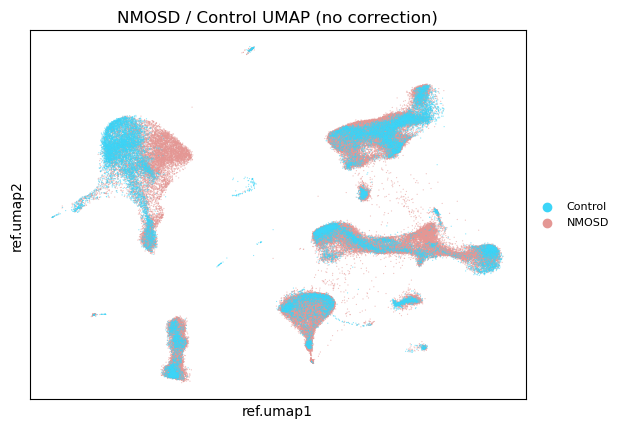

In [6]:
# 測試:使用未做harmony，直接用azimuth後的投影座標
#-----------------------------------【UMAP圖 標記NMOSD/Control】-----------------------------------
import numpy as np
adata_merged.obs["Condition"] = np.where(
    adata_merged.obs["orig.ident"].astype(str).str.startswith("nmo"),
    "NMOSD",
    "Control"
)

sc.pl.embedding(
    adata_merged,
    basis="ref.umap",
    color="Condition",
    title="NMOSD / Control UMAP (no correction)",
    legend_loc="right margin",
    legend_fontsize=8,
    frameon=True,
    legend_fontoutline=1,
    palette={
        "Control": "#3CD5F8",
        "NMOSD": "#E49794"
    },
    size=3,
    alpha=0.6,
    sort_order=False
)

In [6]:
adata_merged

AnnData object with n_obs × n_vars = 218212 × 16489
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score', 'Condition'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_harmony', 'X_integrated_dr', 'X_pca', 'X_ref.umap'
    varm: 'HARMONY', 'PCs'

In [7]:
adata_merged_celltypel2_df=adata_merged.obs.loc[:,['predicted.celltype.l2','Condition']]

In [8]:
adata_merged_celltypel2_df = adata_merged_celltypel2_df.rename(
    columns={
        "predicted.celltype.l2": "sub_celltype"
    }
)

In [9]:
adata_merged_celltypel2_df.to_csv('/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_Celltype2_Reclustered_v1/My_merged_Azimuth_celltypel2_CellChat.csv')

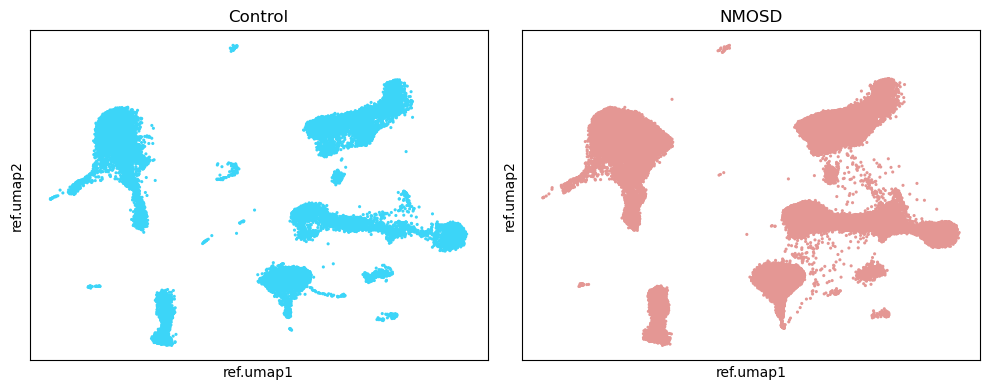

In [7]:
import matplotlib.pyplot as plt
adata_control = adata_merged[adata_merged.obs["Condition"] == "Control"].copy()
adata_nmosd   = adata_merged[adata_merged.obs["Condition"] == "NMOSD"].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sc.pl.embedding(
    adata_control,
    basis="ref.umap",
    color="Condition",
    title="Control",
    legend_loc=None,
    frameon=True,
    palette={"Control": "#3CD5F8"},
    size=20,
    ax=axes[0],
    show=False
)

sc.pl.embedding(
    adata_nmosd,
    basis="ref.umap",
    color="Condition",
    title="NMOSD",
    legend_loc=None,
    frameon=True,
    palette={"NMOSD": "#E49794"},
    size=20,
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.show()

In [4]:
adata_merged.obs['predicted.celltype.l1.score']

nmo008_ACACTGACAATGAAAC-1      0.685193
nmo008_AAGCCGCGTCGAAAGC-1      1.000000
nmo008_TCAGATGGTCAACTGT-1      1.000000
nmo008_CTAACTTGTTAAAGTG-1      1.000000
nmo008_AGAGCTTAGAGTAAGG-1      0.852914
                                 ...   
Control3_TTTGTCACACGGACAA-1    0.961912
Control3_TTTGTCACAGCAGTTT-1    0.902620
Control3_TTTGTCAGTCTTCAAG-1    1.000000
Control3_TTTGTCATCAATCACG-1    0.967224
Control3_TTTGTCATCTGTCCGT-1    1.000000
Name: predicted.celltype.l1.score, Length: 218212, dtype: float64

In [5]:
# Celltype1 predicted score <0.75 的比例
s = adata_merged.obs['predicted.celltype.l1.score'].astype(float)

mask = s.notna()
n_total = int(mask.sum())
n_lt = int((s[mask] < 0.75).sum())
pct_lt = n_lt / n_total * 100

print(f"Total (non-NA): {n_total}")
print(f"<0.75: {n_lt}  ({pct_lt:.2f}%)")

Total (non-NA): 218212
<0.75: 30036  (13.76%)


In [6]:
adata_merged.obs.loc[adata_merged.obs["predicted.celltype.l1"] == "B","predicted.celltype.l2"].unique()

array(['Plasmablast', 'B naive', 'B intermediate', 'B memory', 'cDC1',
       'CD8 TEM', 'dnT'], dtype=object)

In [7]:
# 確認obsm已加入'X_harmony'
adata_merged

AnnData object with n_obs × n_vars = 218212 × 16489
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_harmony', 'X_integrated_dr', 'X_pca', 'X_ref.umap'
    varm: 'HARMONY', 'PCs'

In [8]:
import numpy as np
adata_merged.obs["Condition"] = np.where(
    adata_merged.obs["orig.ident"].astype(str).str.startswith("nmo"),
    "NMOSD",
    "Control"
)

In [9]:
adata_merged.obs["Condition"]

nmo008_ACACTGACAATGAAAC-1        NMOSD
nmo008_AAGCCGCGTCGAAAGC-1        NMOSD
nmo008_TCAGATGGTCAACTGT-1        NMOSD
nmo008_CTAACTTGTTAAAGTG-1        NMOSD
nmo008_AGAGCTTAGAGTAAGG-1        NMOSD
                                ...   
Control3_TTTGTCACACGGACAA-1    Control
Control3_TTTGTCACAGCAGTTT-1    Control
Control3_TTTGTCAGTCTTCAAG-1    Control
Control3_TTTGTCATCAATCACG-1    Control
Control3_TTTGTCATCTGTCCGT-1    Control
Name: Condition, Length: 218212, dtype: object

In [10]:
adata_predicted=adata_merged.copy()

In [11]:
# 把 celltype1 predicted score<0.75 標為Unknown
adata_predicted.obs.loc[adata_predicted.obs['predicted.celltype.l1.score']<0.75,'predicted.celltype.l1']='Unknown'

In [12]:
adata_predicted.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,predicted.celltype.l1.score,predicted.celltype.l1,predicted.celltype.l2.score,predicted.celltype.l2,predicted.celltype.l3.score,predicted.celltype.l3,mapping.score,Condition
nmo008_ACACTGACAATGAAAC-1,nmo008,11860.0,2988,3.971332,0.685193,Unknown,0.624930,CD4 TCM,0.479567,CD4 TCM_1,0.160075,NMOSD
nmo008_AAGCCGCGTCGAAAGC-1,nmo008,11752.0,2838,3.556841,1.000000,CD4 T,1.000000,CD4 TCM,0.987932,CD4 TCM_2,0.821969,NMOSD
nmo008_TCAGATGGTCAACTGT-1,nmo008,11642.0,3070,3.848136,1.000000,CD4 T,1.000000,CD4 TCM,0.992778,CD4 TCM_2,0.949871,NMOSD
nmo008_CTAACTTGTTAAAGTG-1,nmo008,10934.0,3116,5.341138,1.000000,CD4 T,1.000000,CD4 TCM,1.000000,CD4 TCM_2,0.907426,NMOSD
nmo008_AGAGCTTAGAGTAAGG-1,nmo008,10910.0,3136,6.186984,0.852914,CD8 T,0.852914,CD8 TEM,0.469027,CD8 TEM_1,0.324083,NMOSD
...,...,...,...,...,...,...,...,...,...,...,...,...
Control3_TTTGTCACACGGACAA-1,Control3,4684.0,1876,2.625961,0.961912,other T,0.898177,MAIT,0.898177,MAIT,0.824499,Control
Control3_TTTGTCACAGCAGTTT-1,Control3,2438.0,1224,1.886792,0.902620,CD8 T,0.886428,CD8 TEM,0.758866,CD8 TEM_2,0.558437,Control
Control3_TTTGTCAGTCTTCAAG-1,Control3,2902.0,1424,1.654032,1.000000,NK,1.000000,NK,1.000000,NK_2,0.811304,Control
Control3_TTTGTCATCAATCACG-1,Control3,3851.0,1240,1.843677,0.967224,CD4 T,0.909714,CD4 TCM,0.909714,CD4 TCM_1,0.856634,Control


In [13]:
#載入我的已分群Adata
adata_clustered=sc.read_h5ad('/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_protein_coding_genes/Adata/Leiden_all_results(Harmony_nn_25_res_0.6).h5ad')

In [14]:
adata_predicted

AnnData object with n_obs × n_vars = 218212 × 16489
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score', 'Condition'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_harmony', 'X_integrated_dr', 'X_pca', 'X_ref.umap'
    varm: 'HARMONY', 'PCs'

In [15]:
#parameters
cluster_key = "leiden_nn25_res0.6" #原始分群label
label_key = "predicted.celltype.l1" #scVANI預測的結果
n_neighbors=25
ndim_pca=50

In [16]:
#把"predicted_label"、"dataset"加入leiden分群好的adata中
adata_predicted.obs[cluster_key]=adata_clustered.obs[cluster_key]


In [17]:
viz = AZIMUTHvisualizer(adata_predicted, adata_clustered,use_rep='X_harmony',ndim_pca=ndim_pca, base_output="../Dataset/My_merged_protein_coding_genes_TEST")
viz.map_celltype(cluster_key, label_key)
viz.prepare_umap(n_neighbors=n_neighbors)
viz.plot_umap_and_composition(cluster_key)
viz.evaluate_clustering(cluster_key,label_key)

Mapped leiden_nn25_res0.6 cell types done!
UMAP computed using 25 neighbors and 50 PCs.
All plots saved to: ../Dataset/My_merged_protein_coding_genes_TEST/Harmony_Azimuth_plot/Harmony50/leiden_nn25_res0.6/predicted_label
ARI: 0.5003, NMI: 0.6546, V-measure: 0.6546
ARI & NMI & Ｖ-measure evaluation points saved to: ../Dataset/My_merged_protein_coding_genes_TEST/Harmony_Azimuth_evaluation/Harmony50/leiden_nn25_res0.6_predicted.celltype.l1.csv


,Evaluation Index,Score
0,ARI,0.500290
1,NMI,0.654612
2,V-measure,0.654612


In [18]:
adata_query = viz.export_celltype_composition(cluster_key,label_key)

   leiden_nn25_res0.6 Dominant_celltype  Percentage
0                   0             CD4 T    0.747243
1                   1             CD8 T    0.723788
2                   2                NK    0.956913
3                   3             CD4 T    0.835157
4                   4              Mono    0.957653
5                   5                 B    0.999540
6                   6             CD8 T    0.728576
7                   7                 B    0.999729
8                   8             CD4 T    0.909979
9                   9           other T    0.787540
10                 10              Mono    0.998777
11                 11                NK    0.932284
12                 12             CD8 T    0.445607
13                 13             CD4 T    0.546307
14                 14                DC    0.301344
15                 15              Mono    0.792208
Cell-type composition saved to: ../Dataset/My_merged_protein_coding_genes_TEST/Harmony_Azimuth_celltype_composition/

In [19]:
adata_query.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,predicted.celltype.l1.score,predicted.celltype.l1,predicted.celltype.l2.score,predicted.celltype.l2,predicted.celltype.l3.score,predicted.celltype.l3,mapping.score,Condition,leiden_nn25_res0.6,cluster_annotation
nmo008_ACACTGACAATGAAAC-1,nmo008,11860.0,2988,3.971332,0.685193,Unknown,0.624930,CD4 TCM,0.479567,CD4 TCM_1,0.160075,NMOSD,3,CD4 T
nmo008_AAGCCGCGTCGAAAGC-1,nmo008,11752.0,2838,3.556841,1.000000,CD4 T,1.000000,CD4 TCM,0.987932,CD4 TCM_2,0.821969,NMOSD,3,CD4 T
nmo008_TCAGATGGTCAACTGT-1,nmo008,11642.0,3070,3.848136,1.000000,CD4 T,1.000000,CD4 TCM,0.992778,CD4 TCM_2,0.949871,NMOSD,3,CD4 T
nmo008_CTAACTTGTTAAAGTG-1,nmo008,10934.0,3116,5.341138,1.000000,CD4 T,1.000000,CD4 TCM,1.000000,CD4 TCM_2,0.907426,NMOSD,3,CD4 T
nmo008_AGAGCTTAGAGTAAGG-1,nmo008,10910.0,3136,6.186984,0.852914,CD8 T,0.852914,CD8 TEM,0.469027,CD8 TEM_1,0.324083,NMOSD,1,CD8 T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Control3_TTTGTCACACGGACAA-1,Control3,4684.0,1876,2.625961,0.961912,other T,0.898177,MAIT,0.898177,MAIT,0.824499,Control,9,other T
Control3_TTTGTCACAGCAGTTT-1,Control3,2438.0,1224,1.886792,0.902620,CD8 T,0.886428,CD8 TEM,0.758866,CD8 TEM_2,0.558437,Control,1,CD8 T
Control3_TTTGTCAGTCTTCAAG-1,Control3,2902.0,1424,1.654032,1.000000,NK,1.000000,NK,1.000000,NK_2,0.811304,Control,2,NK
Control3_TTTGTCATCAATCACG-1,Control3,3851.0,1240,1.843677,0.967224,CD4 T,0.909714,CD4 TCM,0.909714,CD4 TCM_1,0.856634,Control,0,CD4 T


In [39]:
import pandas as pd

clu = "leiden_nn25_res0.6"
l1  = "predicted.celltype.l1"

bad = ["12","13","14"] # 小於0.5比例的群
sub = adata_query[adata_query.obs[clu].isin(bad)].copy()

# 所有 celltype
all_celltypes = adata_query.obs[l1].astype(str).unique()

counts = pd.crosstab(sub.obs[clu], sub.obs[l1]).reindex(columns=all_celltypes, fill_value=0)  #列:群 行:celltype
mix    = pd.crosstab(sub.obs[clu], sub.obs[l1], normalize="index").reindex(columns=all_celltypes, fill_value=0) #讓每列總合為1

print(f'Cluster12、13、14 percentage🔻\n\n{mix},\n')
print(f'Cluster12、13、14 counts🔻\n\n{counts},\n')


Cluster12、13、14 percentage🔻

predicted.celltype.l1   Unknown     CD4 T     CD8 T        NK     other  \
leiden_nn25_res0.6                                                        
12                     0.192469  0.267782  0.445607  0.019874  0.065900   
13                     0.147714  0.546307  0.037515  0.000000  0.000000   
14                     0.228407  0.142035  0.015355  0.001919  0.024952   

predicted.celltype.l1   other T         B        DC  Mono  
leiden_nn25_res0.6                                         
12                     0.006276  0.000000  0.002092     0  
13                     0.268464  0.000000  0.000000     0  
14                     0.000000  0.285988  0.301344     0  ,

Cluster12、13、14 counts🔻

predicted.celltype.l1  Unknown  CD4 T  CD8 T  NK  other  other T    B   DC  \
leiden_nn25_res0.6                                                           
12                         184    256    426  19     63        6    0    2   
13                         126    

In [21]:
adata_query.obs['predicted.celltype.l1'].value_counts()

predicted.celltype.l1
CD4 T      66511
CD8 T      42220
NK         33760
Unknown    30036
B          22713
Mono       18228
other T     3865
DC           469
other        410
Name: count, dtype: int64

In [28]:
celltypel1_pct = (adata_query.obs["predicted.celltype.l1"]
                 .value_counts(normalize=True) * 100)

celltypel1_pct_str = celltypel1_pct.round(2).astype(str) + " %"
celltypel1_pct_str


predicted.celltype.l1
CD4 T      30.48 %
CD8 T      19.35 %
NK         15.47 %
Unknown    13.76 %
B          10.41 %
Mono        8.35 %
other T     1.77 %
DC          0.21 %
other       0.19 %
Name: proportion, dtype: object

In [23]:
# adata_query.write_h5ad(f"/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_protein_coding_genes_V2/Adata/Harmony_pc{ndim_pca}_{cluster_key}_celltype_result.h5ad")

### **檢查Celltype.l2 score<0.75 的比例**

In [40]:
adata_predicted_celltypel2=adata_merged.copy()

In [41]:
# 把 celltype2 predicted score<0.75 標為Unknown
adata_predicted_celltypel2.obs.loc[adata_predicted_celltypel2.obs['predicted.celltype.l2.score']<0.75,'predicted.celltype.l2']='Unknown'

In [42]:
adata_predicted_celltypel2.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,predicted.celltype.l1.score,predicted.celltype.l1,predicted.celltype.l2.score,predicted.celltype.l2,predicted.celltype.l3.score,predicted.celltype.l3,mapping.score,Condition
nmo008_ACACTGACAATGAAAC-1,nmo008,11860.0,2988,3.971332,0.685193,CD4 T,0.624930,Unknown,0.479567,CD4 TCM_1,0.160075,NMOSD
nmo008_AAGCCGCGTCGAAAGC-1,nmo008,11752.0,2838,3.556841,1.000000,CD4 T,1.000000,CD4 TCM,0.987932,CD4 TCM_2,0.821969,NMOSD
nmo008_TCAGATGGTCAACTGT-1,nmo008,11642.0,3070,3.848136,1.000000,CD4 T,1.000000,CD4 TCM,0.992778,CD4 TCM_2,0.949871,NMOSD
nmo008_CTAACTTGTTAAAGTG-1,nmo008,10934.0,3116,5.341138,1.000000,CD4 T,1.000000,CD4 TCM,1.000000,CD4 TCM_2,0.907426,NMOSD
nmo008_AGAGCTTAGAGTAAGG-1,nmo008,10910.0,3136,6.186984,0.852914,CD8 T,0.852914,CD8 TEM,0.469027,CD8 TEM_1,0.324083,NMOSD
...,...,...,...,...,...,...,...,...,...,...,...,...
Control3_TTTGTCACACGGACAA-1,Control3,4684.0,1876,2.625961,0.961912,other T,0.898177,MAIT,0.898177,MAIT,0.824499,Control
Control3_TTTGTCACAGCAGTTT-1,Control3,2438.0,1224,1.886792,0.902620,CD8 T,0.886428,CD8 TEM,0.758866,CD8 TEM_2,0.558437,Control
Control3_TTTGTCAGTCTTCAAG-1,Control3,2902.0,1424,1.654032,1.000000,NK,1.000000,NK,1.000000,NK_2,0.811304,Control
Control3_TTTGTCATCAATCACG-1,Control3,3851.0,1240,1.843677,0.967224,CD4 T,0.909714,CD4 TCM,0.909714,CD4 TCM_1,0.856634,Control


In [ ]:
celltypel2_pct = (adata_predicted_celltypel2.obs["predicted.celltype.l2"]
                 .value_counts(normalize=True) * 100)

celltypel2_pct_str = celltypel2_pct.round(2).astype(str) + " %"
celltypel2_pct_str


predicted.celltype.l2
Unknown              31.18 %
CD4 TCM              17.36 %
NK                   14.58 %
CD8 TEM              12.87 %
CD14 Mono             7.06 %
B naive               5.14 %
CD8 Naive             1.84 %
CD8 TCM                1.5 %
MAIT                  1.48 %
B intermediate         1.3 %
B memory              1.11 %
CD16 Mono             1.08 %
CD4 CTL               0.69 %
NK_CD56bright         0.68 %
Treg                   0.6 %
CD4 TEM               0.49 %
CD4 Naive             0.44 %
ILC                   0.15 %
cDC2                  0.14 %
dnT                   0.12 %
pDC                   0.07 %
Plasmablast           0.06 %
Platelet              0.03 %
gdT                   0.01 %
NK Proliferating      0.01 %
HSPC                  0.01 %
CD4 Proliferating      0.0 %
Eryth                  0.0 %
cDC1                   0.0 %
ASDC                   0.0 %
CD8 Proliferating      0.0 %
Name: proportion, dtype: object

: 